# Лабораторная работа № 1 ТМО

# Кудабаева Эвита ИУ5-62Б


## Источник данных: Встроенный датасет библиотеки `scikit-learn` (`sklearn.datasets.load_iris`).

## Предметная область: Ботаника, классификация растений.

Описание:
Набор данных "Ирисы Фишера" (Iris flower data set) — это классический набор данных для задач классификации и визуализации. Он содержит информацию о 150 экземплярах ирисов, принадлежащих к одному из трёх видов:
- Iris Setosa (0)
- Iris Versicolor (1)
- Iris Virginica (2)

Признаки (Features):
Для каждого цветка измерялись 4 числовых признака (все в сантиметрах):
1.  Sepal Length (cm) - Длина чашелистика.
2.  Sepal Width (cm) - Ширина чашелистика.
3.  Petal Length (cm) - Длина лепестка.
4.  Petal Width (cm) - Ширина лепестка.

Целевая переменная (Target):
- Species (Вид) - название вида ириса (закодирована числами 0, 1, 2).

In [ ]:
# 2. Импорт библиотек и загрузка данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

sns.set_style("whitegrid")

%matplotlib inline

print("Библиотеки успешно импортированы!")


iris_data = load_iris(as_frame=True)
df = iris_data.frame
df.head()

Библиотеки успешно импортированы!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# 3. Основные характеристики датасета

print("="*50)
print("3.1 Общая информация о датасете")
print("="*50)
df.info()

print("\n" + "="*50)
print("3.2 Размерность данных")
print("="*50)
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

print("\n" + "="*50)
print("3.3 Статистическое описание числовых признаков")
print("="*50)
df.describe()

print("\n" + "="*50)
print("3.4 Проверка наличия пропусков (NaN)")
print("="*50)

df.isnull().sum()

print("\n" + "="*50)
print("3.5 Распределение целевой переменной (количество цветков каждого вида)")
print("="*50)
df['target'].value_counts().sort_index()

3.1 Общая информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

3.2 Размерность данных
Количество строк: 150
Количество столбцов: 5

3.3 Статистическое описание числовых признаков

3.4 Проверка наличия пропусков (NaN)

3.5 Распределение целевой переменной (количество цветков каждого вида)


target
0    50
1    50
2    50
Name: count, dtype: int64

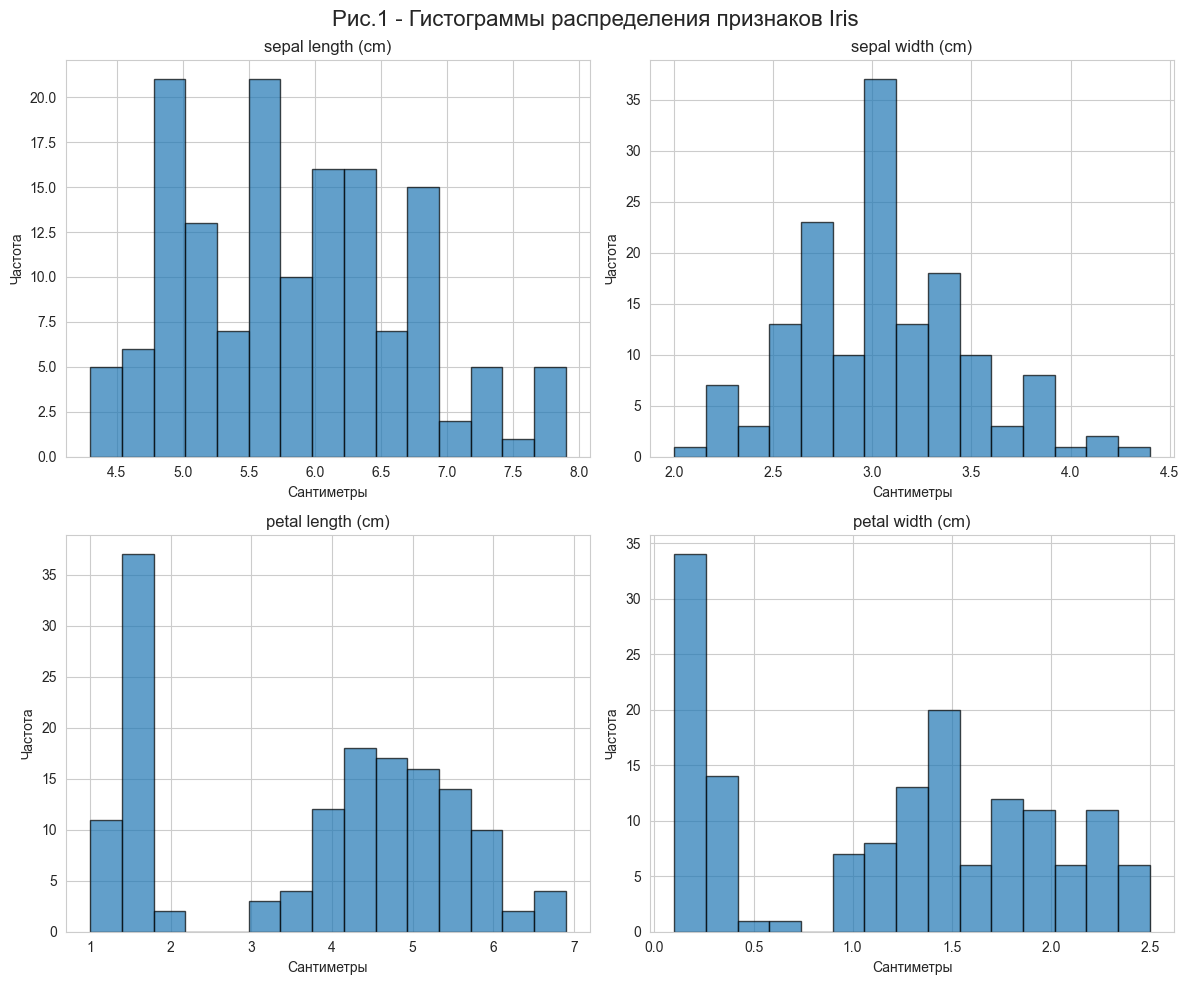

In [4]:
# 4.1 Гистограммы распределения признаков


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Рис.1 - Гистограммы распределения признаков Iris', fontsize=16)
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    axes[row, col].hist(df[feature], bins=15, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('Сантиметры')
    axes[row, col].set_ylabel('Частота')

plt.tight_layout()
plt.show()

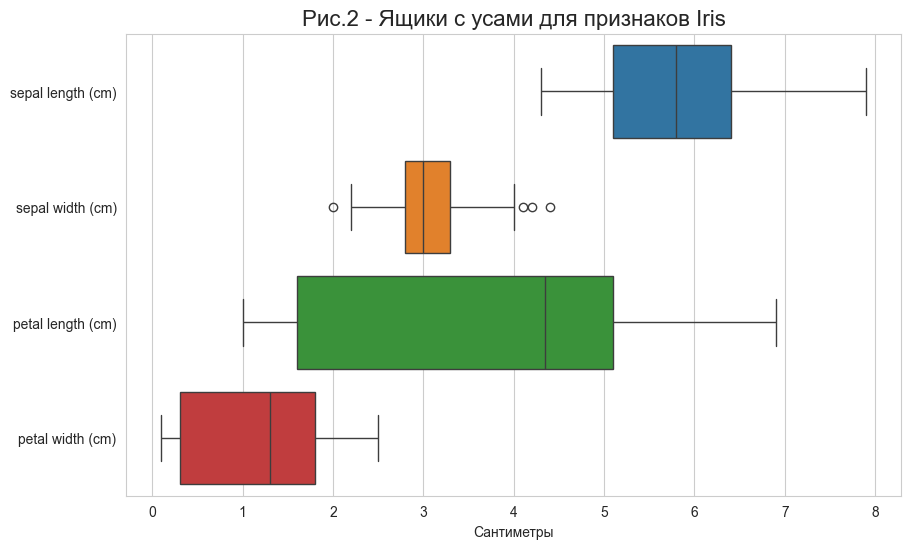

In [5]:
# 4.2 Ящики с усами (Box plots)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[features], orient='h')
plt.title('Рис.2 - Ящики с усами для признаков Iris', fontsize=16)
plt.xlabel('Сантиметры')
plt.show()

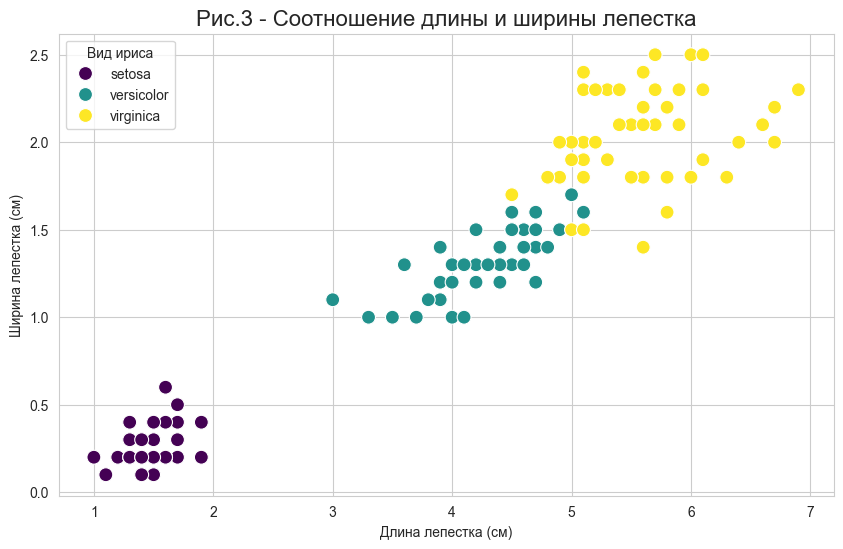

In [3]:
# 4.3 Диаграммы рассеяния
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target', palette='viridis', s=100)
plt.title('Рис.3 - Соотношение длины и ширины лепестка', fontsize=16)
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
species_names = iris_data.target_names
handles, labels = scatter.get_legend_handles_labels()
scatter.legend(handles, species_names, title='Вид ириса')
plt.show()

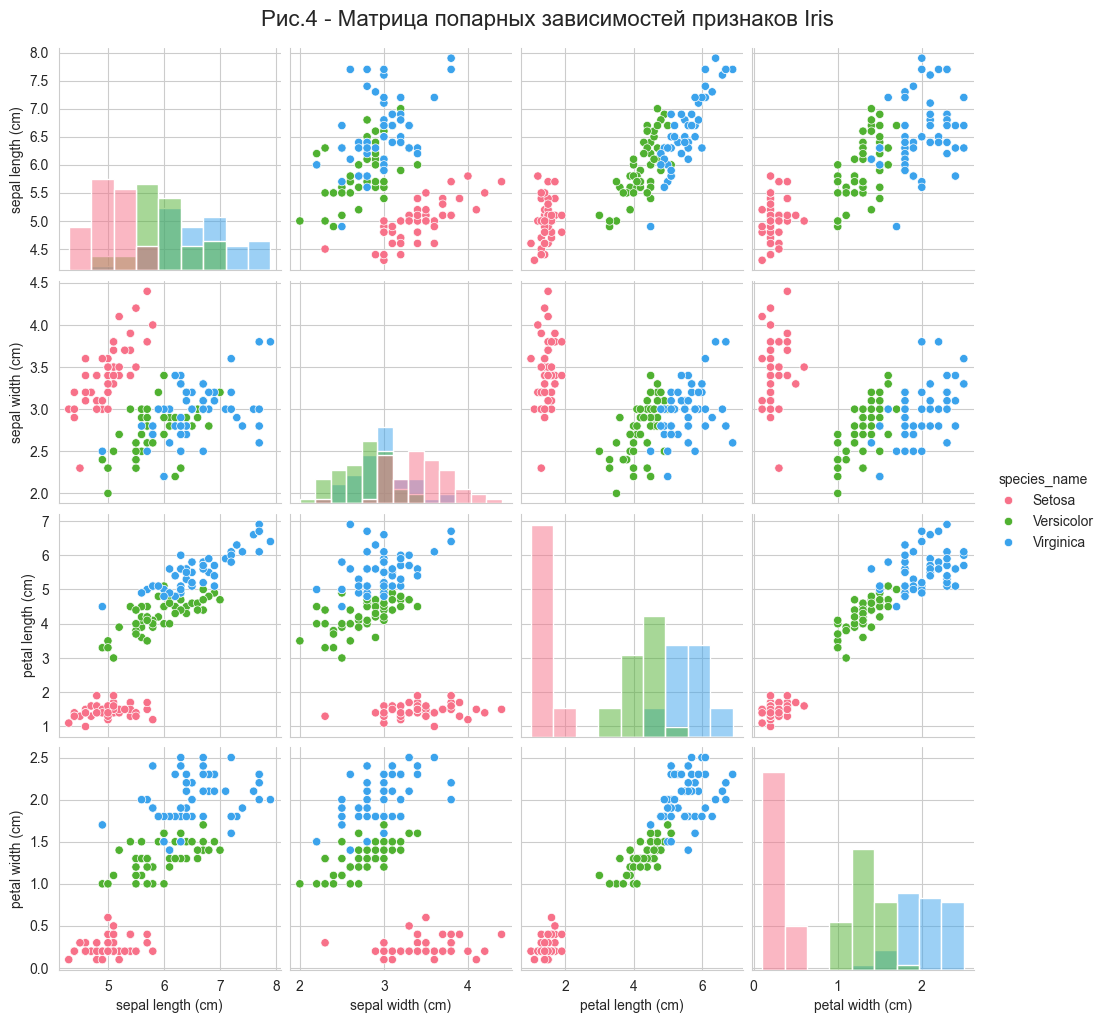

In [7]:
# 4.4 Матрица Pairplot

df['species_name'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
g = sns.pairplot(df, vars=features, hue='species_name', palette='husl', diag_kind='hist')
g.fig.suptitle('Рис.4 - Матрица попарных зависимостей признаков Iris', y=1.02, fontsize=16)
plt.show()

Матрица корреляции Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  



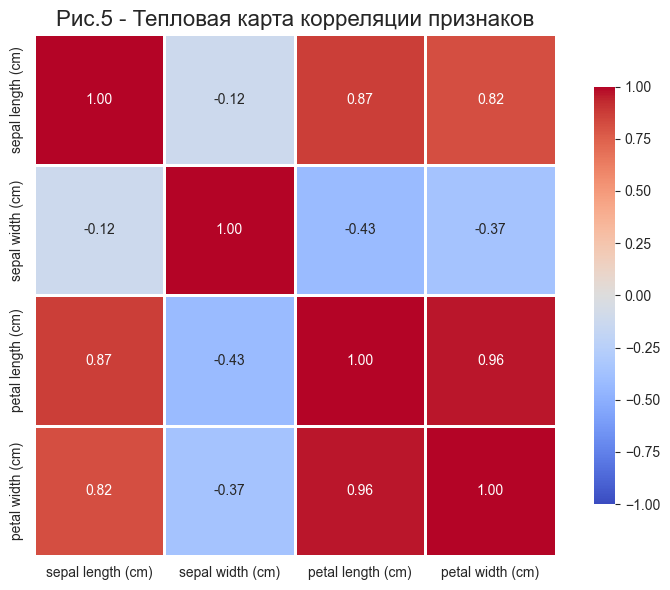


АНАЛИЗ КОРРЕЛЯЦИИ ПРИЗНАКОВ

1. Сильные корреляции (|r| > 0.7):
   • sepal length (cm)    и petal length (cm)   : +0.872
   • sepal length (cm)    и petal width (cm)    : +0.818
   • petal length (cm)    и petal width (cm)    : +0.963

2. Максимальная корреляция:
   • Максимальная корреляция между petal length (cm) и petal width (cm): 0.963

3. Минимальная корреляция (самая сильная отрицательная):
   • Минимальная корреляция между sepal width (cm) и petal length (cm): -0.428


In [4]:
# 5. Корреляционный анализ
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr_matrix = df[features].corr()

print("Матрица корреляции Пирсона:")
print(corr_matrix)
print("\n" + "="*60)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Рис.5 - Тепловая карта корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("АНАЛИЗ КОРРЕЛЯЦИИ ПРИЗНАКОВ")
print("="*60)
print("\n1. Сильные корреляции (|r| > 0.7):")
strong_corr = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append((features[i], features[j], corr_value))
            print(f"   • {features[i]:20} и {features[j]:20}: {corr_value:+.3f}")

print("\n2. Максимальная корреляция:")
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
max_corr_value = upper_triangle.max().max()
max_corr_pair = upper_triangle.stack().idxmax()
print(f"   • Максимальная корреляция между {max_corr_pair[0]} и {max_corr_pair[1]}: {max_corr_value:.3f}")
print("\n3. Минимальная корреляция (самая сильная отрицательная):")
min_corr_value = upper_triangle.min().min()
min_corr_pair = upper_triangle.stack().idxmin()
print(f"   • Минимальная корреляция между {min_corr_pair[0]} и {min_corr_pair[1]}: {min_corr_value:.3f}")



# 4. Интерпретация результатов

# Анализ длины и ширины лепестка

Длина и ширина лепестка имеют очень сильную положительную корреляцию
Это означает, что с увеличением длины лепестка почти всегда увеличивается и его ширина.
Такая высокая корреляция указывает на то, что эти два признака несут похожую информацию.

# Анализ длины чашелистика и длины лепестка
Длина чашелистика и длина лепестка также сильно коррелируют
Это логично, так как у более крупных цветов обычно все части крупнее.

# Анализ отрицательной корреляции
Ширина чашелистика имеет умеренную отрицательную корреляцию с длиной лепестка
Интересно, что цветы с широкими чашелистиками имеют более короткие лепестки

# Практическое применение
Высокая корреляция между признаками важна для дальнейшего машинного обучения:
- Признаки с корреляцией > 0.9 могут быть избыточными (мультиколлинеарность)
- Для классификации видов ириса достаточно использовать не все 4 признака,
  так как длина и ширина лепестка несут очень похожую информацию
- При построении моделей можно рассмотреть возможность уменьшения размерности
  (например, с помощью PCA - метода главных компонент)